# Notebook 01: Download & Parse

**One Sensor, One Year — Edition 1: India Breathes**

First look at the CEA Daily Generation Report data. Goals:
- Load and inspect the data
- Understand column meanings (resolve the TOT ambiguity)
- Parse dates, rename columns for readability
- Filter to calendar year 2024
- Check for missing data
- Save a clean processed CSV

Data source: [Robbie Andrew's India Energy Data](https://robbieandrew.github.io/india/)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

## 1. Load the raw data

In [2]:
# Load CEA Daily Generation Report
raw = pd.read_csv('../data/raw/CEA_DGR_data.csv')
print(f'Shape: {raw.shape}')
print(f'Date range: {raw["yyyymmdd"].min()} to {raw["yyyymmdd"].max()}')
raw.head()

Shape: (2916, 17)
Date range: 20180401 to 20260325


,yyyymmdd,CEA.DGR.COL,CEA.DGR.LIG,CEA.DGR.GAS,CEA.DGR.DIE,CEA.DGR.HSO,CEA.DGR.NAP,CEA.DGR.MFU,CEA.DGR.THM,CEA.DGR.NUC,CEA.DGR.HYD,CEA.DGR.BHU,CEA.DGR.TOT,CEA.DGR.WND,CEA.DGR.SOL,CEA.DGR.OTH,CEA.DGR.RES
0,20180401,2702.66,88.44,133.10,0.27,0.0,0.0,NaN,2924.47,114.25,178.47,2.44,3219.63,NaN,NaN,NaN,NaN
1,20180402,2739.58,92.07,140.29,0.27,0.0,0.0,NaN,2972.21,115.87,222.92,0.95,3311.95,NaN,NaN,NaN,NaN
2,20180403,2862.08,95.48,151.42,0.36,0.0,0.0,0.0,3109.34,115.05,256.66,1.01,3482.06,NaN,NaN,NaN,NaN
3,20180404,2907.16,95.60,149.56,0.51,0.0,0.0,0.0,3152.83,115.58,259.00,2.82,3530.23,NaN,NaN,NaN,NaN
4,20180405,2904.87,91.98,148.78,0.49,0.0,0.0,0.0,3146.12,113.90,241.07,2.82,3503.91,NaN,NaN,NaN,NaN


In [3]:
# Load metadata to understand columns
with open('../data/raw/CEA_DGR_metadata.json') as f:
    metadata = json.load(f)

print('Column definitions:')
for field in metadata['fields']:
    print(f"  {field['name']:20s} → {field['title']}")

Column definitions:
  yyyymmdd             → Date
  CEA.DGR.COL          → Generation: Coal
  CEA.DGR.LIG          → Generation: Lignite
  CEA.DGR.GAS          → Generation: Natural Gas
  CEA.DGR.DIE          → Generation: Diesel
  CEA.DGR.HSO          → Generation: High-Speed Diesel
  CEA.DGR.NAP          → Generation: Naphtha
  CEA.DGR.MFU          → Generation: Multi Fuel
  CEA.DGR.THM          → Generation: Total (excl. RES) Thermal
  CEA.DGR.NUC          → Generation: Nuclear
  CEA.DGR.HYD          → Generation: Hydro
  CEA.DGR.BHU          → Generation: Bhutan imp.
  CEA.DGR.TOT          → Generation: Total (excl. RES)
  CEA.DGR.WND          → Generation: Wind
  CEA.DGR.SOL          → Generation: Solar
  CEA.DGR.OTH          → Generation: Other
  CEA.DGR.RES          → Generation: Renewable Energy Sources


## 2. The TOT Mystery — Resolved

The brief warned that `CEA.DGR.TOT` is "confusingly named." The metadata confirms:
- **TOT = "Generation: Total (excl. RES)"** — it's Thermal + Nuclear + Hydro + Bhutan
- **RES = "Generation: Renewable Energy Sources"** — Wind + Solar + Other
- **True total generation = TOT + RES**

Let's verify this numerically.

In [4]:
# Verify: TOT = THM + NUC + HYD + BHU
raw['_check_tot'] = raw['CEA.DGR.THM'] + raw['CEA.DGR.NUC'] + raw['CEA.DGR.HYD'] + raw['CEA.DGR.BHU']
diff = (raw['CEA.DGR.TOT'] - raw['_check_tot']).dropna()
print(f'TOT vs (THM+NUC+HYD+BHU) — max discrepancy: {diff.abs().max():.4f} MU')
print(f'Mean discrepancy: {diff.abs().mean():.4f} MU')
print('✓ TOT = THM + NUC + HYD + BHU (confirmed)' if diff.abs().max() < 0.1 else '✗ Discrepancy found!')

# Verify: RES = WND + SOL + OTH
raw['_check_res'] = raw['CEA.DGR.WND'] + raw['CEA.DGR.SOL'] + raw['CEA.DGR.OTH']
diff_res = (raw['CEA.DGR.RES'] - raw['_check_res']).dropna()
print(f'\nRES vs (WND+SOL+OTH) — max discrepancy: {diff_res.abs().max():.4f} MU')
print('✓ RES = WND + SOL + OTH (confirmed)' if diff_res.abs().max() < 0.1 else '✗ Discrepancy found!')

raw.drop(columns=['_check_tot', '_check_res'], inplace=True)

TOT vs (THM+NUC+HYD+BHU) — max discrepancy: 0.0000 MU
Mean discrepancy: 0.0000 MU
✓ TOT = THM + NUC + HYD + BHU (confirmed)

RES vs (WND+SOL+OTH) — max discrepancy: 18.3800 MU
✗ Discrepancy found!


## 3. Parse dates and rename columns

In [5]:
# Parse date
raw['date'] = pd.to_datetime(raw['yyyymmdd'], format='%Y%m%d')

# Rename to human-readable names
# All values are in MU (Million Units = GWh)
column_map = {
    'CEA.DGR.COL': 'coal',
    'CEA.DGR.LIG': 'lignite',
    'CEA.DGR.GAS': 'gas',
    'CEA.DGR.DIE': 'diesel',
    'CEA.DGR.HSO': 'hsd',        # High-Speed Diesel
    'CEA.DGR.NAP': 'naphtha',
    'CEA.DGR.MFU': 'multi_fuel',
    'CEA.DGR.THM': 'thermal',    # Total thermal (sum of above)
    'CEA.DGR.NUC': 'nuclear',
    'CEA.DGR.HYD': 'hydro',
    'CEA.DGR.BHU': 'bhutan',     # Bhutan hydro imports
    'CEA.DGR.TOT': 'total_ex_re', # Total EXCLUDING renewables
    'CEA.DGR.WND': 'wind',
    'CEA.DGR.SOL': 'solar',
    'CEA.DGR.OTH': 'other_re',   # Other renewables
    'CEA.DGR.RES': 'renewables',  # Total renewables (wind+solar+other)
}

df = raw.rename(columns=column_map).drop(columns=['yyyymmdd'])

# Add computed columns
df['total'] = df['total_ex_re'] + df['renewables']  # True total generation

# Reorder: date first, then fuel types, then totals
col_order = ['date', 'coal', 'lignite', 'gas', 'diesel', 'hsd', 'naphtha', 'multi_fuel',
             'thermal', 'nuclear', 'hydro', 'bhutan', 'wind', 'solar', 'other_re',
             'renewables', 'total_ex_re', 'total']
df = df[col_order]

print(f'Full dataset: {len(df)} days, {df["date"].min().date()} to {df["date"].max().date()}')
df.head()

Full dataset: 2916 days, 2018-04-01 to 2026-03-25


,date,coal,lignite,gas,diesel,hsd,naphtha,multi_fuel,thermal,nuclear,hydro,bhutan,wind,solar,other_re,renewables,total_ex_re,total
0,2018-04-01,2702.66,88.44,133.10,0.27,0.0,0.0,NaN,2924.47,114.25,178.47,2.44,NaN,NaN,NaN,NaN,3219.63,NaN
1,2018-04-02,2739.58,92.07,140.29,0.27,0.0,0.0,NaN,2972.21,115.87,222.92,0.95,NaN,NaN,NaN,NaN,3311.95,NaN
2,2018-04-03,2862.08,95.48,151.42,0.36,0.0,0.0,0.0,3109.34,115.05,256.66,1.01,NaN,NaN,NaN,NaN,3482.06,NaN
3,2018-04-04,2907.16,95.60,149.56,0.51,0.0,0.0,0.0,3152.83,115.58,259.00,2.82,NaN,NaN,NaN,NaN,3530.23,NaN
4,2018-04-05,2904.87,91.98,148.78,0.49,0.0,0.0,0.0,3146.12,113.90,241.07,2.82,NaN,NaN,NaN,NaN,3503.91,NaN


## 4. Filter to Calendar Year 2024

In [6]:
df24 = df[(df['date'] >= '2024-01-01') & (df['date'] <= '2024-12-31')].copy()
df24 = df24.reset_index(drop=True)

print(f'2024 dataset: {len(df24)} days (expect 366 — leap year)')
print(f'Date range: {df24["date"].min().date()} to {df24["date"].max().date()}')

# Check for date gaps
expected_dates = pd.date_range('2024-01-01', '2024-12-31')
missing_dates = expected_dates.difference(df24['date'])
print(f'Missing dates: {len(missing_dates)}')
if len(missing_dates) > 0:
    for d in missing_dates:
        print(f'  {d.date()} ({d.strftime("%A")})')

2024 dataset: 366 days (expect 366 — leap year)
Date range: 2024-01-01 to 2024-12-31
Missing dates: 0


## 5. Missing Data Check

In [7]:
# NaN counts per column in 2024
nans = df24.isnull().sum()
print('NaN counts in 2024:')
for col, count in nans.items():
    if count > 0:
        print(f'  {col:15s}: {count} missing days')

if nans.sum() == 0:
    print('  No missing values!')
else:
    # Which specific dates have NaN in any column?
    nan_rows = df24[df24.isnull().any(axis=1)]
    print(f'\nDates with missing data ({len(nan_rows)} days):')
    for _, row in nan_rows.iterrows():
        missing_cols = [col for col in df24.columns if pd.isna(row[col])]
        print(f'  {row["date"].date()} ({row["date"].strftime("%A")}) — missing: {", ".join(missing_cols)}')

NaN counts in 2024:
  wind           : 1 missing days

Dates with missing data (1 days):
  2024-11-09 (Saturday) — missing: wind


## 6. Quick Overview of the Minor Fuel Types

The brief mentioned coal, lignite, gas — but the data also has diesel, HSD, naphtha, and multi-fuel. How significant are these in 2024?

In [8]:
minor_fuels = ['diesel', 'hsd', 'naphtha', 'multi_fuel']
print('Minor thermal fuels in 2024 (MU/day):')
print(df24[minor_fuels].describe().round(2))
print(f'\nCombined minor fuels as % of total thermal: {(df24[minor_fuels].sum().sum() / df24["thermal"].sum() * 100):.3f}%')
print('→ Negligible. We can safely focus on coal, lignite, and gas for the thermal breakdown.')

Minor thermal fuels in 2024 (MU/day):
       diesel    hsd  naphtha  multi_fuel
count  366.00  366.0    366.0       366.0
mean     1.12    0.0      0.0         0.0
std      0.01    0.0      0.0         0.0
min      1.11    0.0      0.0         0.0
25%      1.11    0.0      0.0         0.0
50%      1.11    0.0      0.0         0.0
75%      1.14    0.0      0.0         0.0
max      1.14    0.0      0.0         0.0

Combined minor fuels as % of total thermal: 0.030%
→ Negligible. We can safely focus on coal, lignite, and gas for the thermal breakdown.


## 7. First Look: Daily Generation Mix in 2024

A quick stacked area chart to see the shape of the year.

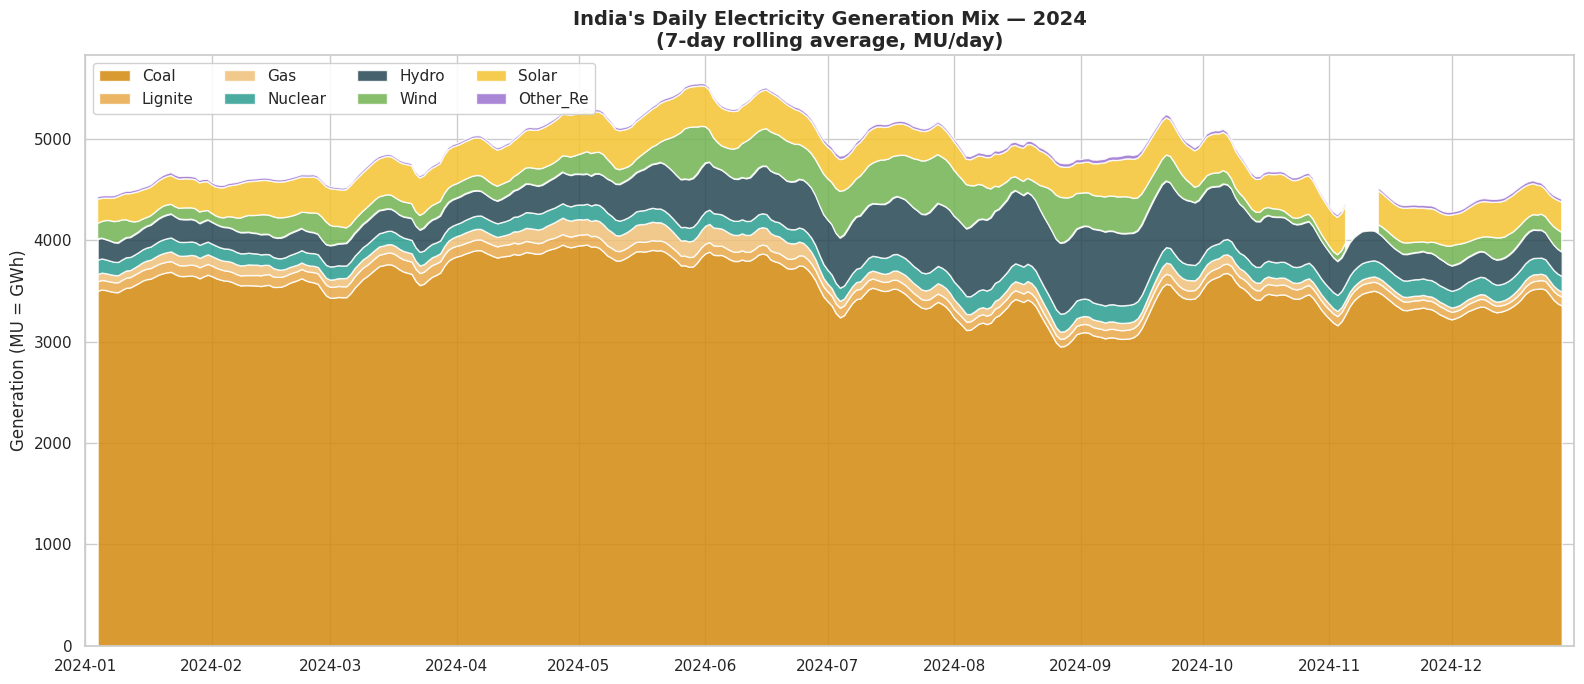

Saved to data/processed/first_look_2024.png


In [9]:
# The main fuel types for visualization
fuel_cols = ['coal', 'lignite', 'gas', 'nuclear', 'hydro', 'wind', 'solar', 'other_re']
fuel_colors = {
    'coal': '#D4890E',      # warm amber
    'lignite': '#E8A849',   # lighter amber
    'gas': '#F0C078',       # light orange
    'nuclear': '#2A9D8F',   # teal
    'hydro': '#264653',     # deep blue
    'wind': '#72B352',      # green
    'solar': '#F4C430',     # golden yellow
    'other_re': '#9B72CF',  # soft purple
}

fig, ax = plt.subplots(figsize=(16, 7))

# Use 7-day rolling average for smoother visualization
plot_data = df24.set_index('date')[fuel_cols].rolling(7, center=True).mean()

ax.stackplot(plot_data.index, *[plot_data[col] for col in fuel_cols],
             labels=[c.title() for c in fuel_cols],
             colors=[fuel_colors[c] for c in fuel_cols],
             alpha=0.85)

ax.set_title("India's Daily Electricity Generation Mix — 2024\n(7-day rolling average, MU/day)",
             fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Generation (MU = GWh)')
ax.legend(loc='upper left', ncol=4, framealpha=0.9)
ax.set_xlim(plot_data.index.min(), plot_data.index.max())

plt.tight_layout()
plt.savefig('../data/processed/first_look_2024.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to data/processed/first_look_2024.png')

## 8. Save Processed Data

In [10]:
# Save the full cleaned dataset (all years)
df.to_csv('../data/processed/india_all_years.csv', index=False)
print(f'Saved india_all_years.csv: {len(df)} rows')

# Save the 2024 filtered dataset
df24.to_csv('../data/processed/india_2024.csv', index=False)
print(f'Saved india_2024.csv: {len(df24)} rows')

# Save 2022-2024 for YoY comparison (Notebook 06)
df_yoy = df[(df['date'] >= '2022-01-01') & (df['date'] <= '2024-12-31')].copy()
df_yoy.to_csv('../data/processed/india_2022_2024.csv', index=False)
print(f'Saved india_2022_2024.csv: {len(df_yoy)} rows')

Saved india_all_years.csv: 2916 rows
Saved india_2024.csv: 366 rows
Saved india_2022_2024.csv: 1096 rows


## Key Findings

1. **TOT excludes renewables** — confirmed. True total = TOT + RES.
2. **366 days in 2024** (leap year) — check for any missing dates above.
3. **Minor thermal fuels (diesel, HSD, naphtha, multi-fuel) are negligible** — <0.1% of thermal. We'll focus on coal, lignite, gas.
4. **Renewable data has a few more NaN days** than conventional — likely reporting lag from the separate CEA renewable report.
5. **Bhutan imports are tiny and often zero** — interesting but not a major factor.
6. **The stacked area chart already tells a story** — coal dominates, but watch the seasonal swings in hydro and wind.

→ Next: Notebook 02 — Basic Statistics